In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib import font_manager

root = "./data/외내항.csv"

sns.set_theme(style="whitegrid")

font_path = r"C:\Windows\Fonts\malgun.ttf"
font_prop = font_manager.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(font_name)


Malgun Gothic


In [47]:
df = pd.read_csv(root,encoding='euc-kr')
df

,연도,월,분기,청코드,내외항구분,수출입구분명,시설코드,시설명,부두구분명,아외국구분,적공구분,컨테이너수(10피트),컨테이너수(20피트),컨테이너수(40피트),컨테이너수(기타),전체개수,전체물동량
0,2024,3,1,신항,외항,수입,6,신항 W 정박지,일반부두,외국선,적컨,0,3,8,0,11,19.00
1,2024,4,2,신항,외항,수입,6,신항 W 정박지,일반부두,아국선,적컨,0,9,3,0,12,15.00
2,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,공컨,0,1,0,0,1,1.00
3,2024,11,4,신항,외항,수입,7,신항 U 정박지,일반부두,아국선,공컨,0,57,2,0,59,61.00
4,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,적컨,0,31,100,0,131,231.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,2024,7,3,북항,외항,수입환적,8,자성대 부두,컨테이너부두,외국선,적컨,0,8769,6434,0,15203,21637.00
2405,2024,7,3,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,7719,6438,2,14159,20599.50
2406,2024,7,3,북항,외항,수입,8,자성대 부두,컨테이너부두,외국선,적컨,0,7818,7253,0,15071,22324.00
2407,2024,11,4,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,2519,2018,3,4540,6561.75


In [48]:
df.shape

(2409, 17)

In [49]:
df.head(3)

,연도,월,분기,청코드,내외항구분,수출입구분명,시설코드,시설명,부두구분명,아외국구분,적공구분,컨테이너수(10피트),컨테이너수(20피트),컨테이너수(40피트),컨테이너수(기타),전체개수,전체물동량
0,2024,3,1,신항,외항,수입,6,신항 W 정박지,일반부두,외국선,적컨,0,3,8,0,11,19.0
1,2024,4,2,신항,외항,수입,6,신항 W 정박지,일반부두,아국선,적컨,0,9,3,0,12,15.0
2,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,공컨,0,1,0,0,1,1.0


In [50]:
df['전체물동량'].isna()

0       False
1       False
2       False
3       False
4       False
        ...  
2404    False
2405    False
2406    False
2407    False
2408    False
Name: 전체물동량, Length: 2409, dtype: bool

In [51]:
df.columns.tolist()

['연도',
 '월',
 '분기',
 '청코드',
 '내외항구분',
 '수출입구분명',
 '시설코드',
 '시설명',
 '부두구분명',
 '아외국구분',
 '적공구분',
 '컨테이너수(10피트)',
 '컨테이너수(20피트)',
 '컨테이너수(40피트)',
 '컨테이너수(기타)',
 '전체개수',
 '전체물동량']

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2409 entries, 0 to 2408
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   연도           2409 non-null   int64  
 1   월            2409 non-null   int64  
 2   분기           2409 non-null   int64  
 3   청코드          2409 non-null   str    
 4   내외항구분        2409 non-null   str    
 5   수출입구분명       2409 non-null   str    
 6   시설코드         2409 non-null   int64  
 7   시설명          2409 non-null   str    
 8   부두구분명        2409 non-null   str    
 9   아외국구분        2409 non-null   str    
 10  적공구분         2409 non-null   str    
 11  컨테이너수(10피트)  2409 non-null   int64  
 12  컨테이너수(20피트)  2409 non-null   int64  
 13  컨테이너수(40피트)  2409 non-null   int64  
 14  컨테이너수(기타)    2409 non-null   int64  
 15  전체개수         2409 non-null   int64  
 16  전체물동량        2409 non-null   float64
dtypes: float64(1), int64(9), str(7)
memory usage: 478.9 KB


In [53]:
df["기준월"] = pd.to_datetime(
    df["연도"].astype(str)
    + "-"
    + df["월"].astype(str)
)

df[["연도", "월", "기준월"]].head()

,연도,월,기준월
0,2024,3,2024-03-01
1,2024,4,2024-04-01
2,2024,11,2024-11-01
3,2024,11,2024-11-01
4,2024,11,2024-11-01


In [54]:
total_volume = df["전체물동량"].sum()
total_containers = df["전체개수"].sum()
monthly_average = df.groupby("기준월")["전체물동량"].sum().mean()

print(f"전체 물동량: {total_volume:,.0f}")
print(f"전체 컨테이너 개수: {total_containers:,}")
print(f"월평균 물동량: {monthly_average:,.0f}")

전체 물동량: 24,402,020
전체 컨테이너 개수: 15,039,292
월평균 물동량: 2,033,502


In [55]:
monthly_summary = (
    df.groupby("기준월", as_index=False)
      .agg(
          전체물동량=("전체물동량", "sum"),
          전체개수=("전체개수", "sum")
      )
      .sort_values("기준월")
)

monthly_summary

,기준월,전체물동량,전체개수
0,2024-01-01,1992396.50,1236949
1,2024-02-01,1879271.50,1157122
2,2024-03-01,2143065.75,1324091
3,2024-04-01,2046147.00,1267817
4,2024-05-01,2098141.00,1289788
5,2024-06-01,2090886.75,1292598
6,2024-07-01,2107241.75,1297877
7,2024-08-01,2052806.00,1261867
8,2024-09-01,1877152.00,1153621
9,2024-10-01,2049390.75,1256312


In [56]:
monthly_summary["전월대비증감률"] = (
    monthly_summary["전체물동량"]
    .pct_change()
    .mul(100)
)

monthly_summary

,기준월,전체물동량,전체개수,전월대비증감률
0,2024-01-01,1992396.50,1236949,NaN
1,2024-02-01,1879271.50,1157122,-5.677836
2,2024-03-01,2143065.75,1324091,14.037048
3,2024-04-01,2046147.00,1267817,-4.522435
4,2024-05-01,2098141.00,1289788,2.541069
5,2024-06-01,2090886.75,1292598,-0.345747
6,2024-07-01,2107241.75,1297877,0.782204
7,2024-08-01,2052806.00,1261867,-2.583270
8,2024-09-01,1877152.00,1153621,-8.556775
9,2024-10-01,2049390.75,1256312,9.175536


In [57]:
monthly_summary.style.format({
    "전체물동량": "{:,.0f}",
    "전체개수": "{:,.0f}",
    "전월대비증감률": "{:+.1f}%"
})


,기준월,전체물동량,전체개수,전월대비증감률
0,2024-01-01 00:00:00,"1,992,396","1,236,949",+nan%
1,2024-02-01 00:00:00,"1,879,272","1,157,122",-5.7%
2,2024-03-01 00:00:00,"2,143,066","1,324,091",+14.0%
3,2024-04-01 00:00:00,"2,046,147","1,267,817",-4.5%
4,2024-05-01 00:00:00,"2,098,141","1,289,788",+2.5%
5,2024-06-01 00:00:00,"2,090,887","1,292,598",-0.3%
6,2024-07-01 00:00:00,"2,107,242","1,297,877",+0.8%
7,2024-08-01 00:00:00,"2,052,806","1,261,867",-2.6%
8,2024-09-01 00:00:00,"1,877,152","1,153,621",-8.6%
9,2024-10-01 00:00:00,"2,049,391","1,256,312",+9.2%


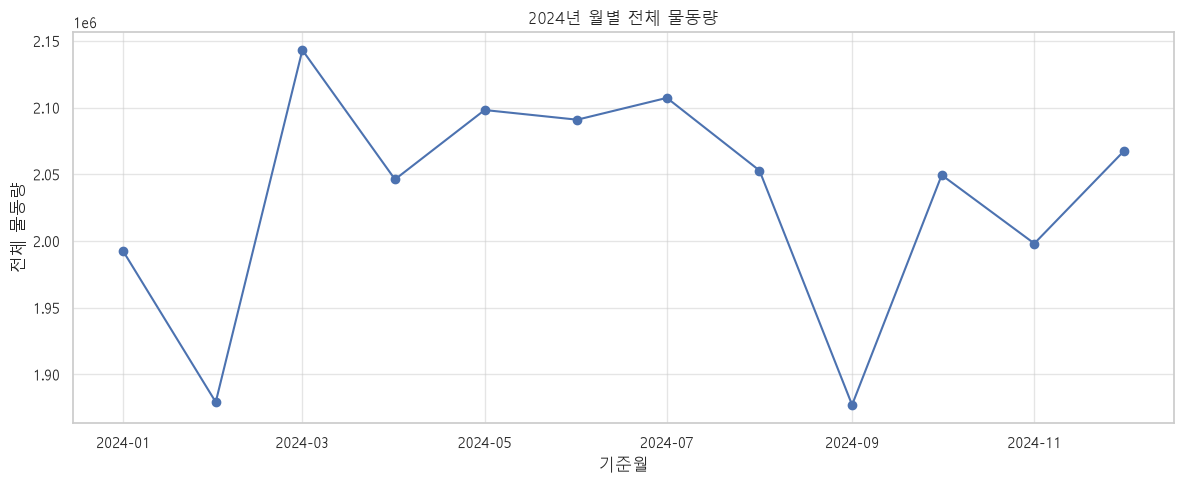

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_summary["기준월"],
    monthly_summary["전체물동량"],
    marker="o"
)

plt.title("2024년 월별 전체 물동량")
plt.xlabel("기준월")
plt.ylabel("전체 물동량")


plt.tight_layout()
plt.show()

In [59]:
port_summary = (
    df.groupby("청코드", as_index=False)
      .agg(
          전체물동량=("전체물동량", "sum"),
          전체개수=("전체개수", "sum")
      )
      .sort_values("전체물동량", ascending=False)
)

port_summary["물동량비중"] = (
    port_summary["전체물동량"]
    / port_summary["전체물동량"].sum()
    * 100
)

port_summary

,청코드,전체물동량,전체개수,물동량비중
2,신항,17880496.0,10605237,73.274655
1,북항,6512510.0,4429329,26.688405
0,감천,9014.0,4726,0.036940


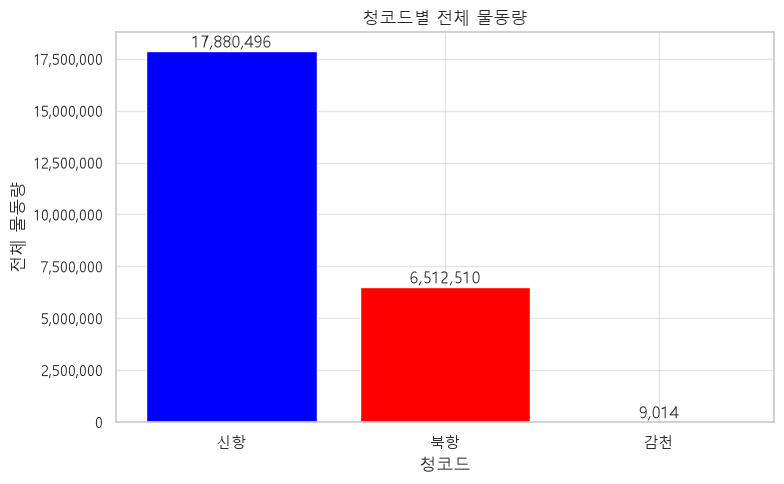

In [60]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    port_summary["청코드"],
    port_summary["전체물동량"],
    color=["blue", "red", "green"]
)

plt.title("청코드별 전체 물동량")
plt.xlabel("청코드")
plt.ylabel("전체 물동량")

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)

for bar, value in zip(bars, port_summary["전체물동량"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()

In [61]:
facility_summary = (
    df.groupby("시설명", as_index=False)
      .agg(
          전체물동량=("전체물동량", "sum"),
          전체개수=("전체개수", "sum")
      )
      .sort_values("전체물동량", ascending=False)
)

facility_summary["물동량비중"] = (
    facility_summary["전체물동량"]
    / facility_summary["전체물동량"].sum()
    * 100
)

facility_top10 = facility_summary.head(10)

facility_top10

,시설명,전체물동량,전체개수,물동량비중
19,신항2부두,4957906.25,2965231,20.317606
20,신항3부두,3076160.25,1848627,12.606171
18,신항1부두,3018314.75,1749165,12.369118
15,신선대 부두,2813334.50,1898264,11.529105
21,신항4부두,2560274.25,1517492,10.492059
22,신항5부두,2422973.00,1408302,9.929395
3,감만부두,1543293.25,1052924,6.324449
26,자성대 부두,1443379.75,995318,5.915001
23,신항6부두,1238460.50,748878,5.075238
24,신항7부두,563725.00,338134,2.310157


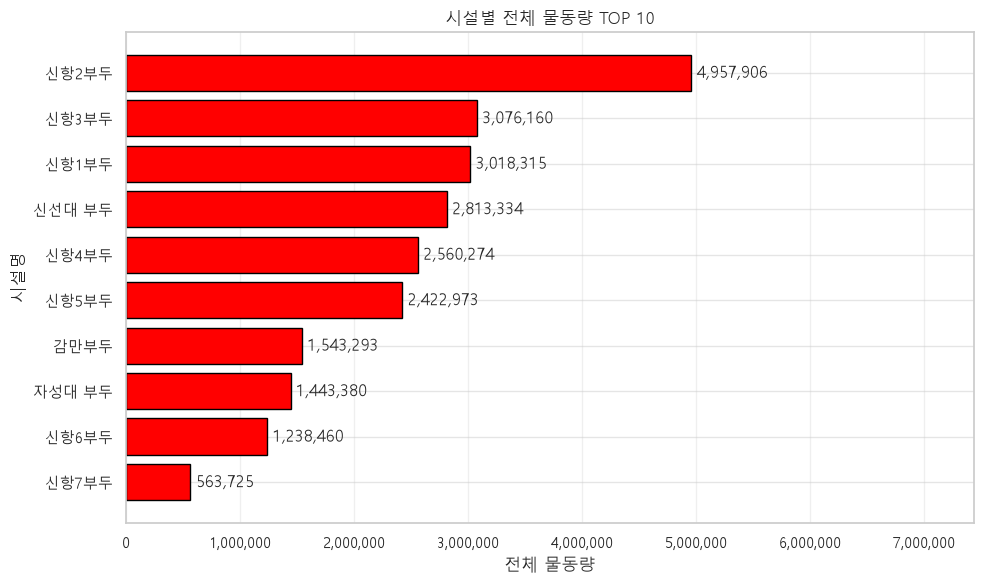

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    facility_top10["시설명"],
    facility_top10["전체물동량"],
    color="red",
    edgecolor="black",
)

ax.invert_yaxis()

ax.set_title("시설별 전체 물동량 TOP 10")
ax.set_xlabel("전체 물동량")
ax.set_ylabel("시설명")

ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in facility_top10["전체물동량"]
    ],
    padding=4
)

ax.set_xlim(
    0,
    facility_top10["전체물동량"].max() * 1.5
)

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
top3_share = (facility_summary.head(3)["전체물동량"].sum()/facility_summary["전체물동량"].sum())*100
print(f"상위 3개 시설 물동량 비중: {top3_share:.1f}%")

상위 3개 시설 물동량 비중: 45.3%


In [64]:
df

,연도,월,분기,청코드,내외항구분,수출입구분명,시설코드,시설명,부두구분명,아외국구분,적공구분,컨테이너수(10피트),컨테이너수(20피트),컨테이너수(40피트),컨테이너수(기타),전체개수,전체물동량,기준월
0,2024,3,1,신항,외항,수입,6,신항 W 정박지,일반부두,외국선,적컨,0,3,8,0,11,19.00,2024-03-01
1,2024,4,2,신항,외항,수입,6,신항 W 정박지,일반부두,아국선,적컨,0,9,3,0,12,15.00,2024-04-01
2,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,공컨,0,1,0,0,1,1.00,2024-11-01
3,2024,11,4,신항,외항,수입,7,신항 U 정박지,일반부두,아국선,공컨,0,57,2,0,59,61.00,2024-11-01
4,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,적컨,0,31,100,0,131,231.00,2024-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,2024,7,3,북항,외항,수입환적,8,자성대 부두,컨테이너부두,외국선,적컨,0,8769,6434,0,15203,21637.00,2024-07-01
2405,2024,7,3,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,7719,6438,2,14159,20599.50,2024-07-01
2406,2024,7,3,북항,외항,수입,8,자성대 부두,컨테이너부두,외국선,적컨,0,7818,7253,0,15071,22324.00,2024-07-01
2407,2024,11,4,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,2519,2018,3,4540,6561.75,2024-11-01


In [65]:
trade_summary= df.groupby('수출입구분명').agg(
          전체물동량=("전체물동량", "sum"),
          전체개수=("전체개수", "sum")
)
trade_summary = trade_summary.sort_values(
    "전체물동량",
    ascending=False
)
trade_summary

,전체물동량,전체개수
수출입구분명,,
수입환적,6794732.25,4044726
수출환적,6702451.75,3993054
수출,5495144.75,3524638
수입,5409691.25,3476874


In [66]:
trade_summary = trade_summary.reset_index()
trade_sum = trade_summary.loc[
    trade_summary['수출입구분명'].isin(["수출환적", "수입환적"]),
    "전체물동량"
].sum()
trade_summary

,수출입구분명,전체물동량,전체개수
0,수입환적,6794732.25,4044726
1,수출환적,6702451.75,3993054
2,수출,5495144.75,3524638
3,수입,5409691.25,3476874


In [67]:
trade_summary["물동량비중"] = (
    trade_summary["전체물동량"] / total_volume * 100
)

transshipment_share = trade_sum / total_volume * 100

trade_summary
print(f"환적 물동량: {trade_sum:,.0f}")
print(f"환적 비중: {transshipment_share:.1f}%")

환적 물동량: 13,497,184
환적 비중: 55.3%


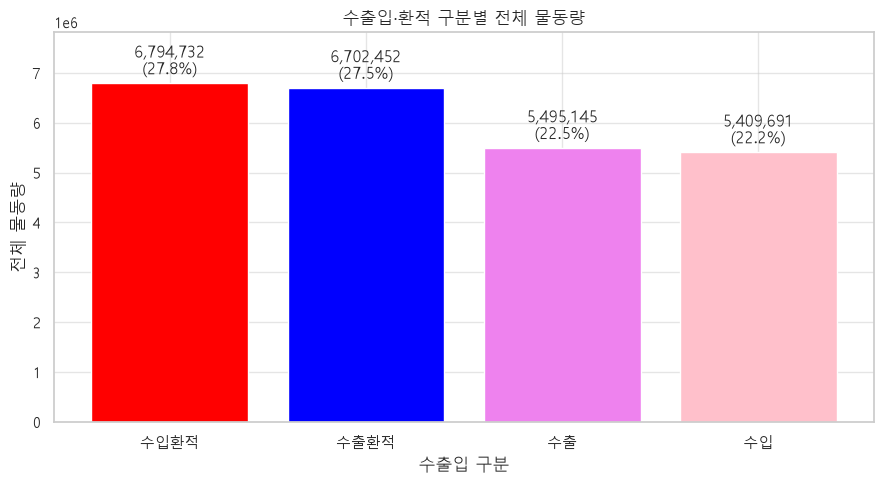

In [68]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    trade_summary["수출입구분명"],
    trade_summary["전체물동량"],
    color=["red", "blue", "violet", "pink"]
)

ax.set_title("수출입·환적 구분별 전체 물동량")
ax.set_xlabel("수출입 구분")
ax.set_ylabel("전체 물동량")

labels = [
    f"{volume:,.0f}\n({share:.1f}%)"
    for volume, share in zip(
        trade_summary["전체물동량"],
        trade_summary["물동량비중"]
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4
)


ax.margins(y=0.15)
plt.tight_layout()
plt.show()

In [69]:
df

,연도,월,분기,청코드,내외항구분,수출입구분명,시설코드,시설명,부두구분명,아외국구분,적공구분,컨테이너수(10피트),컨테이너수(20피트),컨테이너수(40피트),컨테이너수(기타),전체개수,전체물동량,기준월
0,2024,3,1,신항,외항,수입,6,신항 W 정박지,일반부두,외국선,적컨,0,3,8,0,11,19.00,2024-03-01
1,2024,4,2,신항,외항,수입,6,신항 W 정박지,일반부두,아국선,적컨,0,9,3,0,12,15.00,2024-04-01
2,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,공컨,0,1,0,0,1,1.00,2024-11-01
3,2024,11,4,신항,외항,수입,7,신항 U 정박지,일반부두,아국선,공컨,0,57,2,0,59,61.00,2024-11-01
4,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,적컨,0,31,100,0,131,231.00,2024-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,2024,7,3,북항,외항,수입환적,8,자성대 부두,컨테이너부두,외국선,적컨,0,8769,6434,0,15203,21637.00,2024-07-01
2405,2024,7,3,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,7719,6438,2,14159,20599.50,2024-07-01
2406,2024,7,3,북항,외항,수입,8,자성대 부두,컨테이너부두,외국선,적컨,0,7818,7253,0,15071,22324.00,2024-07-01
2407,2024,11,4,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,2519,2018,3,4540,6561.75,2024-11-01


In [70]:
grp2 = (
    df.groupby(["청코드", "적공구분"])["전체물동량"]
      .sum()
      .unstack(fill_value=0)
)

grp2["공컨물동량비율(%)"] = (
    grp2["공컨"]
    / (grp2["공컨"] + grp2["적컨"])
    * 100
).round(2)

grp2["적컨물동량비율(%)"] = (
    grp2["적컨"]
    / (grp2["공컨"] + grp2["적컨"])
    * 100
).round(2)

grp2

적공구분,공컨,적컨,공컨물동량비율(%),적컨물동량비율(%)
청코드,,,,
감천,1083.0,7931.0,12.01,87.99
북항,1360130.5,5152379.5,20.88,79.12
신항,2696878.0,15183618.0,15.08,84.92


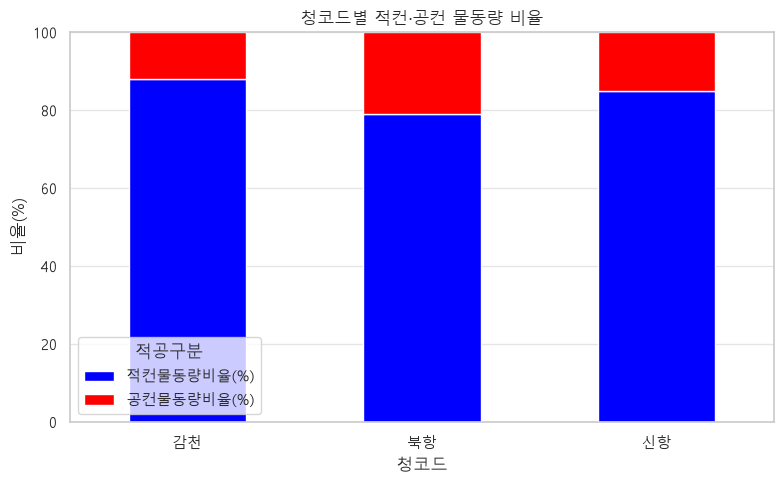

In [71]:
ax = grp2[
    ["적컨물동량비율(%)", "공컨물동량비율(%)"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["blue", "red"]
)

ax.set_title("청코드별 적컨·공컨 물동량 비율")
ax.set_xlabel("청코드")
ax.set_ylabel("비율(%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [72]:
df


,연도,월,분기,청코드,내외항구분,수출입구분명,시설코드,시설명,부두구분명,아외국구분,적공구분,컨테이너수(10피트),컨테이너수(20피트),컨테이너수(40피트),컨테이너수(기타),전체개수,전체물동량,기준월
0,2024,3,1,신항,외항,수입,6,신항 W 정박지,일반부두,외국선,적컨,0,3,8,0,11,19.00,2024-03-01
1,2024,4,2,신항,외항,수입,6,신항 W 정박지,일반부두,아국선,적컨,0,9,3,0,12,15.00,2024-04-01
2,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,공컨,0,1,0,0,1,1.00,2024-11-01
3,2024,11,4,신항,외항,수입,7,신항 U 정박지,일반부두,아국선,공컨,0,57,2,0,59,61.00,2024-11-01
4,2024,11,4,신항,외항,수입환적,7,신항 U 정박지,일반부두,아국선,적컨,0,31,100,0,131,231.00,2024-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2404,2024,7,3,북항,외항,수입환적,8,자성대 부두,컨테이너부두,외국선,적컨,0,8769,6434,0,15203,21637.00,2024-07-01
2405,2024,7,3,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,7719,6438,2,14159,20599.50,2024-07-01
2406,2024,7,3,북항,외항,수입,8,자성대 부두,컨테이너부두,외국선,적컨,0,7818,7253,0,15071,22324.00,2024-07-01
2407,2024,11,4,북항,외항,수출,8,자성대 부두,컨테이너부두,외국선,적컨,0,2519,2018,3,4540,6561.75,2024-11-01


In [73]:
container_size_summary=df[['컨테이너수(10피트)','컨테이너수(20피트)','컨테이너수(40피트)','컨테이너수(기타)']].sum()
container_size_summary = (
    (container_size_summary / total_containers) * 100
).round(2)

container_size_summary.index.name = "컨테이너 규격"
container_size_summary.name = "비중(%)"

container_size_table = container_size_summary.reset_index()

container_size_table

,컨테이너 규격,비중(%)
0,컨테이너수(10피트),0.04
1,컨테이너수(20피트),37.76
2,컨테이너수(40피트),61.91
3,컨테이너수(기타),0.29


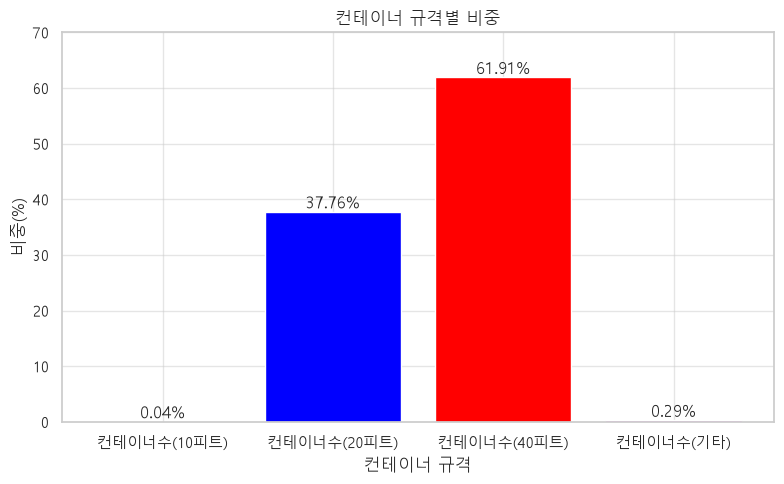

In [74]:
fig, ax2 = plt.subplots(figsize=(8, 5))

bars = ax2.bar(
    container_size_table["컨테이너 규격"],
    container_size_table["비중(%)"],
    color=["pink", "blue", "red", "violet"]
)

ax2.set_title("컨테이너 규격별 비중")
ax2.set_xlabel("컨테이너 규격")
ax2.set_ylabel("비중(%)")
ax2.set_ylim(0, 70)

ax2.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in container_size_table["비중(%)"]
    ]
)

plt.tight_layout()
plt.show()

In [75]:
monthly_port_summary = (
    df.groupby(
        ["기준월", "청코드"],
        as_index=False
    )
    .agg(
        전체물동량=("전체물동량", "sum")
    )
)

monthly_port_summary.head()

,기준월,청코드,전체물동량
0,2024-01-01,감천,601.00
1,2024-01-01,북항,575253.00
2,2024-01-01,신항,1416542.50
3,2024-02-01,감천,765.00
4,2024-02-01,북항,522355.25


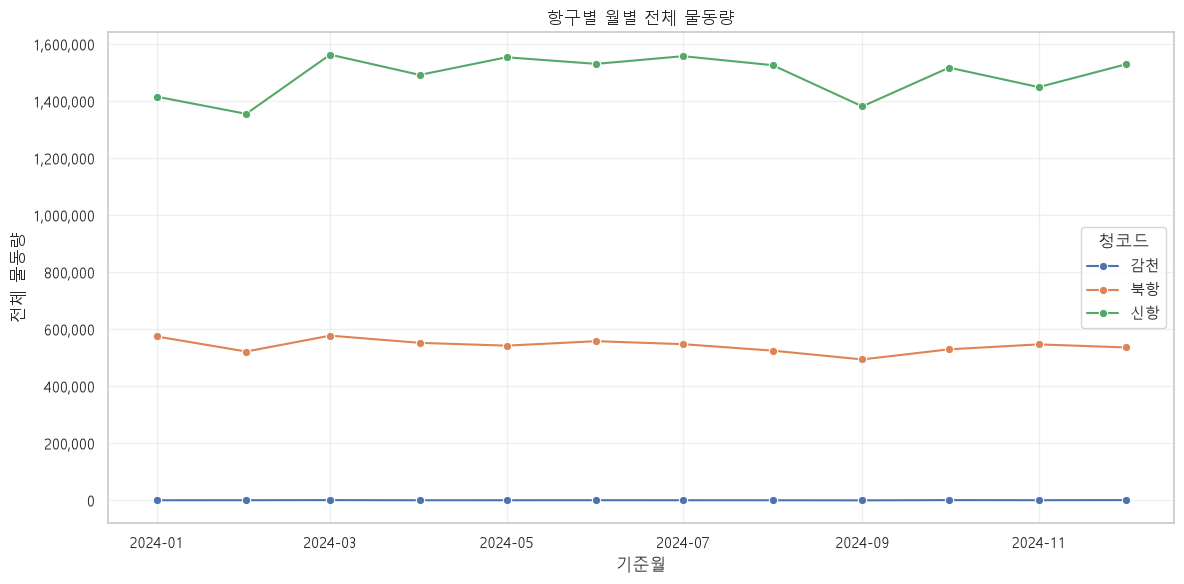

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=monthly_port_summary,
    x="기준월",
    y="전체물동량",
    hue="청코드",
    marker="o",
    ax=ax
)

ax.set_title("항구별 월별 전체 물동량")
ax.set_xlabel("기준월")
ax.set_ylabel("전체 물동량")

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

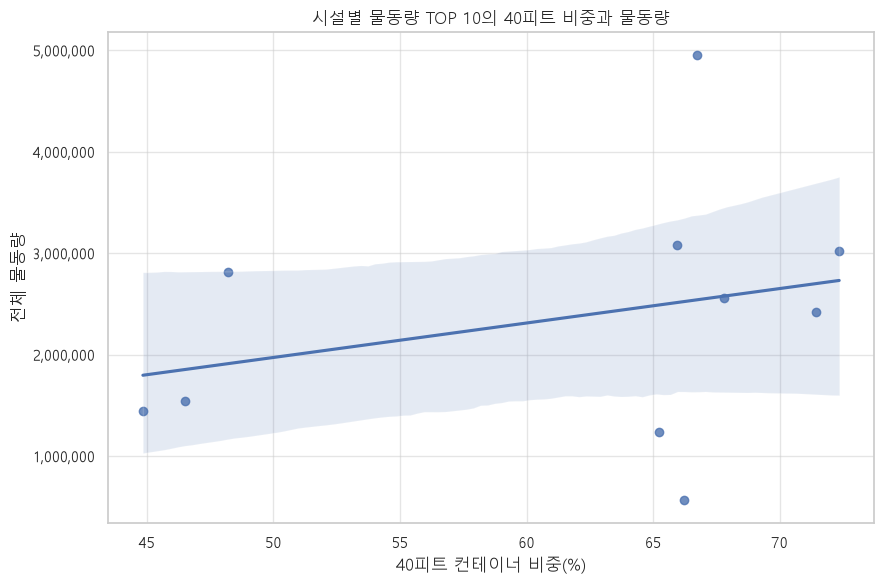

In [77]:
facility_top10 = (
    df.groupby("시설명", as_index=False)
      .agg(
          전체물동량=("전체물동량", "sum"),
          전체개수=("전체개수", "sum"),
          컨테이너40피트=("컨테이너수(40피트)", "sum")
      )
      .sort_values("전체물동량", ascending=False)
      .head(10)
)

facility_top10["40피트비중(%)"] = (
    facility_top10["컨테이너40피트"]
    / facility_top10["전체개수"]
    * 100
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=facility_top10,
    x="40피트비중(%)",
    y="전체물동량",
    ax=ax
)

ax.set_title("시설별 물동량 TOP 10의 40피트 비중과 물동량")
ax.set_xlabel("40피트 컨테이너 비중(%)")
ax.set_ylabel("전체 물동량")

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter("{x:,.0f}")
)

plt.tight_layout()
plt.show()

In [78]:
corr = facility_top10[
    "40피트비중(%)"
].corr(
    facility_top10["전체물동량"]
)

print(corr)

0.29037686399538254


## 최종 데이터 전처리(2024년)
- 전체 물동량·전체 컨테이너 개수·월평균
    - 청코드별 월별 물동량 추정 -> 감소 이유 추정
- 월별 물동량 추이와 전월 대비 증감률
- 청코드별 물동량
- 시설별 물동량 TOP 10
- 수출·수입·환적 구성과 환적 비중
- 청코드별 적컨·공컨 비중
- 컨테이너 규격별 비중